
# Comparison of the K-Means and MiniBatchKMeans clustering algorithms

**Learning Outcomes**
1. Implement a clustering solution using K-Means model from sklearn 
2. Implement a clustering solution using mini-batch K-Means model from sklearn 
3. compare between the performances of both algorithms to appreciate thier subtle differences


We want to compare the performance of the MiniBatchKMeans and KMeans: the MiniBatchKMeans is faster, but gives slightly different results.

We will cluster a dataset, first with KMeans and then with MiniBatchKMeans, and plot the results.
We will also plot the points that are labelled differently between the two algorithms.

Disclaimer: this exercise is adopted from sklearn.

In [1]:
%matplotlib inline

In [2]:
print(__doc__)

import time

import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics.pairwise import pairwise_distances_argmin
from sklearn.datasets import make_blobs



Automatically created module for IPython interactive environment


In [3]:
%set_env OMP_NUM_THREADS=1

env: OMP_NUM_THREADS=1


## Generate sample data

In [4]:
np.random.seed(0)

batch_size = 2056
centers = [[1, 1], [-1, -1], [1, -1]]
n_clusters = len(centers)
X, labels_true = make_blobs(n_samples=3000, centers=centers, cluster_std=0.7)


## Compute clustering with Means

In [5]:
k_means = KMeans(init='k-means++', n_clusters=3, n_init=10)
t0 = time.time()
k_means.fit(X)
t_batch = time.time() - t0

## Compute clustering with MiniBatchKMeans

In [6]:
mbk = MiniBatchKMeans(init='k-means++', n_clusters=3, batch_size=batch_size,
                      n_init=10, max_no_improvement=10, verbose=0)
t0 = time.time()
mbk.fit(X)
t_mini_batch = time.time() - t0


## Plot result

In [7]:
### helper functions
def clust_plot(points, center):
    ax.plot(X[points, 0], X[points, 1], 'o', markerfacecolor=col, marker='o',          markersize=4)
    ax.plot(   center[0],    center[1], '+', markerfacecolor=col, markeredgecolor='k', markersize=16)

def set_fig(title, time, inertia):
    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())
    plt.text(-3.5, 1.8, 'train time: %.2fs\ninertia: %f' %(time, inertia))
    


Plot K-means and mini batch K-means and the differences between them in three subplots.


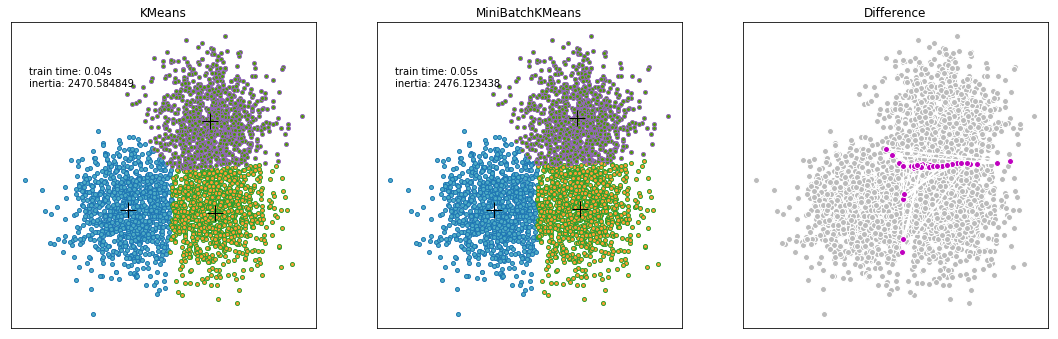

In [8]:
fig = plt.figure(figsize=(15, 5))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.05, top=0.9)
colors = ['#4EACC5', '#FF9C34', '#4E9A06']
# We want to have the same colours for the same cluster from the MiniBatchKMeans and the KMeans algorithm.

# Let's pair the cluster centers per closest one.
k_centers = k_means.cluster_centers_
order = pairwise_distances_argmin(k_means.cluster_centers_, mbk.cluster_centers_)
mbk_centers = mbk.cluster_centers_[order]


k_labels   = pairwise_distances_argmin(X, k_centers)
mbk_labels = pairwise_distances_argmin(X, mbk_centers)

    
# KMeans-------------------------------------------------------------------------------------------------------
ax = fig.add_subplot(1, 3, 1)
for k, col in zip(range(n_clusters), colors):
    clust_points = k_labels == k
    clust_center = k_centers[k]
    clust_plot(clust_points, clust_center)

set_fig('KMeans', t_batch, k_means.inertia_)

# MiniBatchKMeans-----------------------------------------------------------------------------------------------
ax = fig.add_subplot(1, 3, 2)
for k, col in zip(range(n_clusters), colors):
    clust_points = mbk_labels == k
    clust_center = mbk_centers[k]
    clust_plot(clust_points, clust_center)

set_fig('MiniBatchKMeans', t_mini_batch, mbk.inertia_)
    
# Initialise the different array to all False-------------------------------------------------------------------
different = (mbk_labels == 4)
ax = fig.add_subplot(1, 3, 3)

for k in range(n_clusters):
    different += ((k_labels == k) != (mbk_labels == k))

identic = np.logical_not(different)
ax.plot(X[identic,   0], X[identic,   1], 'w', markerfacecolor='#bbbbbb', marker='.',markersize=12)
ax.plot(X[different, 0], X[different, 1], 'w', markerfacecolor='m',       marker='.', markersize=12)
ax.set_title('Difference')
ax.set_xticks(())
ax.set_yticks(())

plt.show()
